In [1]:
import jax
import jax.numpy as jnp
import numpy as np

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

In [2]:
plt.rcParams['font.family'] ='sans-serif'
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.size'] = 6.0
plt.rcParams['ytick.major.size'] = 6.0
plt.rcParams['xtick.major.width'] = 1.0
plt.rcParams['ytick.major.width'] = 1.0
plt.rcParams['xtick.minor.size'] = 4.0
plt.rcParams['ytick.minor.size'] = 4.0
plt.rcParams['xtick.minor.width'] = 0.8
plt.rcParams['ytick.minor.width'] = 0.8
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['font.size'] = 16
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['text.usetex'] = False

In [5]:
import ps_1loop_jax
import ps_1loop_jax.params as ps_params

In [6]:
model = ps_1loop_jax.PowerSpectrum1LoopLPT()

In [7]:
## input linear matter power spectrum as a dictionary
d = np.loadtxt('data/pk_lin_planck18_fid_z0.txt')
pk_data = jnp.vstack((d[:,0], d[:,1]))

## other model parameters
f = 0.578
h = 0.6736
bias = jnp.array([0.71, 0.26, 0.67, -0.2])
ctr = jnp.array([0.0, 0.0, 0.0, 0.0])
stoch = jnp.array([0.0, 0.0, 0.0])
k_nl = 0.25
ndens = 3e-4

params = ps_params.make_lpt_params(f=f, h=h, bias=bias, ctr=ctr, stoch=stoch, k_nl=k_nl, ndens=ndens)

In [9]:
## Output P(k,mu) as jax.numpy array of shape (len(k), len(mu))
k = jnp.linspace(1e-3,0.3,100)
mu = jnp.linspace(0.,1.,11)
%time pkmu = model.get_pkmu(k, mu, pk_data, params)

CPU times: user 152 μs, sys: 150 μs, total: 302 μs
Wall time: 440 μs


## Redshift-space multiples (only $\ell = 0, 2, 4$ are supported)

In [11]:
%time pk0, pk2, pk4 = model.get_pk_ells(k, pk_data, params)

CPU times: user 1.5 ms, sys: 1.1 ms, total: 2.59 ms
Wall time: 910 μs


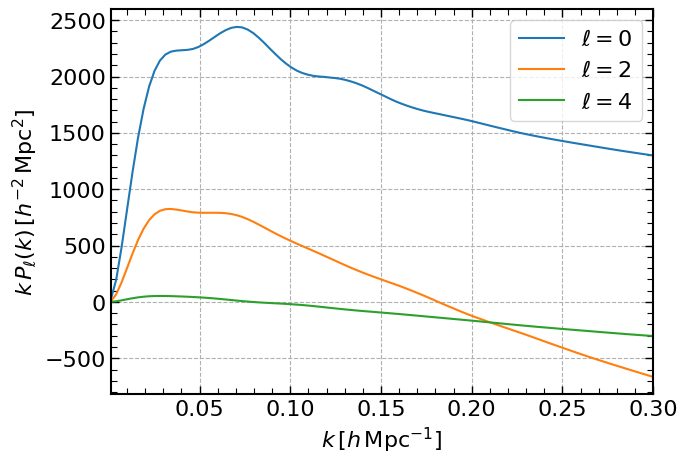

In [12]:
fig = plt.figure(figsize=(7,5))
color = plt.rcParams['axes.prop_cycle'].by_key()['color']
ax = fig.add_subplot()

ax.plot(k, k * pk0, label=r'$\ell = 0$')
ax.plot(k, k * pk2, label=r'$\ell = 2$')
ax.plot(k, k * pk4, label=r'$\ell = 4$')

axs = plt.gcf().get_axes()
for ax in axs:
    plt.sca(ax)
    plt.xlabel(r'$k \, [h \, \mathrm{Mpc}^{-1}]$')
    plt.ylabel(r'$k \, P_{\ell}(k) \, [h^{-2} \, \mathrm{Mpc}^2]$')
    plt.xlim(k.min(), k.max())
    plt.legend(fontsize=16)
    plt.grid(linestyle='--')